In [1]:
# Cell 1: Import Milestone 3 Modules
import sys
import os

# Setup paths
parent = os.path.dirname(os.getcwd())
src_path = os.path.join(parent, 'src')
sys.path.insert(0, src_path)
sys.path.insert(0, os.path.join(src_path, 'synthesis'))
sys.path.insert(0, os.path.join(src_path, 'recommendations'))

# Import new modules
import findings_synthesizer
import recommendation_generator

FindingsSynthesizer = findings_synthesizer.FindingsSynthesizer
RecommendationGenerator = recommendation_generator.RecommendationGenerator

print("✓ Milestone 3 modules imported successfully!")

✓ Milestone 3 modules imported successfully!


In [2]:
# Cell 2: Complete Pipeline with All Milestones
from pathlib import Path
import json
import pandas as pd

# Import all previous modules
sys.path.insert(0, os.path.join(src_path, 'parsers'))
sys.path.insert(0, os.path.join(src_path, 'extractors'))
sys.path.insert(0, os.path.join(src_path, 'validators'))
sys.path.insert(0, os.path.join(src_path, 'models'))

import input_parser, data_extractor, data_validator, parameter_interpreter, pattern_recognition

def complete_blood_report_analysis(file_path):
    """Complete end-to-end blood report analysis pipeline"""
    
    # Milestone 1: Data Ingestion & Parameter Interpretation
    parser = input_parser.InputParser()
    parsed_data = parser.parse(file_path)
    
    extractor = data_extractor.ParameterExtractor()
    extracted_params = extractor.extract(parsed_data)
    
    validator = data_validator.DataValidator()
    validated_params, validation_report = validator.validate_and_standardize(extracted_params)
    
    gender = parsed_data.get('gender')
    age = parsed_data.get('age')
    interpreter = parameter_interpreter.ParameterInterpreter(gender=gender, age=age)
    interpretations = interpreter.interpret(validated_params)
    
    # Milestone 2: Pattern Recognition & Risk Assessment
    pattern_model = pattern_recognition.PatternRecognitionModel()
    pattern_analysis = pattern_model.analyze(interpretations)
    
    # Milestone 3: Synthesis & Recommendations
    synthesizer = FindingsSynthesizer()
    synthesized_findings = synthesizer.synthesize(interpretations, pattern_analysis)
    
    recommender = RecommendationGenerator()
    recommendations = recommender.generate(
        synthesized_findings, 
        pattern_analysis,
        user_context={'gender': gender, 'age': age}
    )
    
    return {
        'parsed_data': parsed_data,
        'interpretations': interpretations,
        'pattern_analysis': pattern_analysis,
        'synthesized_findings': synthesized_findings,
        'recommendations': recommendations,
        'synthesizer': synthesizer,
        'recommender': recommender
    }

# Test on one report
test_file = Path('../data/raw/report_015.json')
result = complete_blood_report_analysis(test_file)

print("="*60)
print("COMPLETE BLOOD REPORT ANALYSIS")
print("="*60)
print(f"\nReport: {result['parsed_data']['report_id']}")
print(f"Patient: {result['parsed_data']['patient_id']}")
print(f"\nAnalysis Steps Completed:")
print("  ✓ Data Ingestion & Parameter Interpretation (Milestone 1)")
print("  ✓ Pattern Recognition & Risk Assessment (Milestone 2)")
print("  ✓ Findings Synthesis & Recommendations (Milestone 3)")

INFO:numexpr.utils:Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 13 recommendations


COMPLETE BLOOD REPORT ANALYSIS

Report: RPT00015
Patient: PAT82692

Analysis Steps Completed:
  ✓ Data Ingestion & Parameter Interpretation (Milestone 1)
  ✓ Pattern Recognition & Risk Assessment (Milestone 2)
  ✓ Findings Synthesis & Recommendations (Milestone 3)


In [3]:
# Cell 3: Display Synthesized Findings
print("="*60)
print("SYNTHESIZED FINDINGS")
print("="*60)
print(result['synthesizer'].get_summary())

SYNTHESIZED FINDINGS
BLOOD TEST ANALYSIS SUMMARY

OVERALL ASSESSMENT:
Analyzed 15 parameters. 13 within normal range.

KEY FINDINGS:
1. Liver Function Concern
   Pattern identified with 100% confidence

IDENTIFIED PATTERNS:
  • Liver Function Concern (Confidence: 100%)

RISK ASSESSMENT:
  • Cardiovascular: LOW (Score: 0/10)
  • Diabetes: LOW (Score: 0.0/10)

RECOMMENDATIONS:
Detailed recommendations have been generated based on your results.
Please review the personalized recommendations section below.



In [4]:
# Cell 4: Display Personalized Recommendations
print("="*60)
print("PERSONALIZED RECOMMENDATIONS")
print("="*60)
print(result['recommender'].format_recommendations())

PERSONALIZED RECOMMENDATIONS
PERSONALIZED HEALTH RECOMMENDATIONS

MEDICAL CONSULTATION:
  1. Rule out hepatitis
  2. Liver function assessment
  3. Consult hepatologist
  4. Liver function evaluation
  5. Rule out liver disease

DIETARY RECOMMENDATIONS:
  1. Limit alcohol consumption
  2. Healthy balanced diet
  3. Limit alcohol
  4. Maintain healthy weight
  5. Reduce fatty foods

LIFESTYLE MODIFICATIONS:
  1. Regular exercise
  2. Avoid hepatotoxic substances

MONITORING PLAN:
  • Repeat blood work
    Frequency: 3-6 months
    Reason: Monitor abnormal values

DISCLAIMER: These recommendations are AI-generated and should
not replace professional medical advice. Always consult with
qualified healthcare providers for medical decisions.



In [5]:
# Cell 5: Process All Reports with Complete Pipeline
test_files = sorted(Path('../data/raw').glob('report_*.json'))

milestone3_results = []
errors = []

print("Processing all reports with complete pipeline...")
print("-" * 60)

for i, test_file in enumerate(test_files, 1):
    try:
        result = complete_blood_report_analysis(test_file)
        
        # Count recommendations
        rec_counts = {
            'dietary': len(result['recommendations'].get('dietary', [])),
            'lifestyle': len(result['recommendations'].get('lifestyle', [])),
            'medical': len(result['recommendations'].get('medical', [])),
            'monitoring': len(result['recommendations'].get('monitoring', []))
        }
        
        milestone3_results.append({
            'file': test_file.name,
            'report_id': result['parsed_data']['report_id'],
            'key_findings': len(result['synthesized_findings']['key_findings']),
            'priority_issues': len(result['synthesized_findings']['priority_issues']),
            'overall_status': result['synthesized_findings']['overall_status']['status'],
            'dietary_recs': rec_counts['dietary'],
            'lifestyle_recs': rec_counts['lifestyle'],
            'medical_recs': rec_counts['medical'],
            'monitoring_recs': rec_counts['monitoring'],
            'total_recommendations': sum(rec_counts.values())
        })
        
        print(f"✓ {i}/20: {test_file.name}")
        
    except Exception as e:
        errors.append({'file': test_file.name, 'error': str(e)})
        print(f"✗ {i}/20: {test_file.name} - Error: {e}")

# Create results dataframe
results_df = pd.DataFrame(milestone3_results)

print("\n" + "="*60)
print("MILESTONE 3 EVALUATION RESULTS")
print("="*60)
print(f"\nTotal Reports Processed: {len(milestone3_results)}")
print(f"Errors: {len(errors)}")
print(f"Success Rate: {len(milestone3_results)/(len(milestone3_results)+len(errors))*100:.1f}%")

print("\nSynthesis Statistics:")
print(f"  Average Key Findings per Report: {results_df['key_findings'].mean():.1f}")
print(f"  Average Priority Issues: {results_df['priority_issues'].mean():.1f}")

print("\nRecommendation Statistics:")
print(f"  Average Dietary Recommendations: {results_df['dietary_recs'].mean():.1f}")
print(f"  Average Lifestyle Recommendations: {results_df['lifestyle_recs'].mean():.1f}")
print(f"  Average Medical Recommendations: {results_df['medical_recs'].mean():.1f}")
print(f"  Total Recommendations Generated: {results_df['total_recommendations'].sum()}")

print("\nOverall Status Distribution:")
print(results_df['overall_status'].value_counts())

# Save results
results_df.to_csv('../outputs/milestone3_results.csv', index=False)
print("\n✓ Results saved to outputs/milestone3_results.csv")

INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 0 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 2 recommendations
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 0 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 2 recommendations
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 0 clinical patterns
INFO:pattern_recognition:C

Processing all reports with complete pipeline...
------------------------------------------------------------
✓ 1/20: report_001.json
✓ 2/20: report_002.json
✓ 3/20: report_003.json
✓ 4/20: report_004.json
✓ 5/20: report_005.json
✓ 6/20: report_006.json
✓ 7/20: report_007.json
✓ 8/20: report_008.json


INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 9 recommendations
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 9 recommendations
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores


✓ 9/20: report_009.json
✓ 10/20: report_010.json


INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 25 recommendations
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 39 recommendations
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores


✓ 11/20: report_011.json
✓ 12/20: report_012.json


INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 9 recommendations
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 13 recommendations
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 13 recommendations
INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_inter

✓ 13/20: report_013.json
✓ 14/20: report_014.json
✓ 15/20: report_015.json
✓ 16/20: report_016.json
✓ 17/20: report_017.json
✓ 18/20: report_018.json
✓ 19/20: report_019.json
✓ 20/20: report_020.json

MILESTONE 3 EVALUATION RESULTS

Total Reports Processed: 20
Errors: 0
Success Rate: 100.0%

Synthesis Statistics:
  Average Key Findings per Report: 0.7
  Average Priority Issues: 1.2

Recommendation Statistics:
  Average Dietary Recommendations: 4.2
  Average Lifestyle Recommendations: 3.1
  Average Medical Recommendations: 3.4
  Total Recommendations Generated: 231

Overall Status Distribution:
overall_status
needs_attention    12
healthy             8
Name: count, dtype: int64

✓ Results saved to outputs/milestone3_results.csv


In [6]:
# Cell 6: Calculate Milestone 3 Success Metrics
print("="*60)
print("MILESTONE 3 SUCCESS METRICS")
print("="*60)

# Metric 1: Summary Coherence
# Check if summaries were generated for all reports
summary_coherence = (results_df['key_findings'] >= 0).sum() / len(results_df) * 100

print(f"\n1. Summary Coherence: {summary_coherence:.1f}%")
print(f"   (Successfully synthesized findings for all reports)")

# Metric 2: Recommendation Relevance
# Check if recommendations were generated for reports with abnormalities
reports_with_issues = results_df[results_df['overall_status'] != 'healthy']
reports_with_recs = results_df[results_df['total_recommendations'] > 0]
recommendation_relevance = len(reports_with_recs) / len(results_df) * 100

print(f"\n2. Recommendation Relevance: {recommendation_relevance:.1f}%")
print(f"   (Generated recommendations for {len(reports_with_recs)} out of {len(results_df)} reports)")
print(f"   Target: >90% | Status: {'✓ PASS' if recommendation_relevance > 90 else '✗ NEEDS IMPROVEMENT'}")

# Metric 3: Recommendation Actionability
# Check average number of recommendations (should be meaningful)
avg_recommendations = results_df['total_recommendations'].mean()
actionability_score = min(avg_recommendations / 5 * 100, 100)  # 5+ recommendations = 100%

print(f"\n3. Recommendation Actionability: {actionability_score:.1f}%")
print(f"   (Average {avg_recommendations:.1f} recommendations per report)")
print(f"   Target: >90% | Status: {'✓ PASS' if actionability_score > 90 else '✗ NEEDS IMPROVEMENT'}")

# Overall milestone status
milestone3_passed = recommendation_relevance > 90 and actionability_score > 90

print("\n" + "="*60)
if milestone3_passed:
    print("🎉 MILESTONE 3: PASSED")
else:
    print("⚠️ MILESTONE 3: NEEDS IMPROVEMENT")
print("="*60)

MILESTONE 3 SUCCESS METRICS

1. Summary Coherence: 100.0%
   (Successfully synthesized findings for all reports)

2. Recommendation Relevance: 100.0%
   (Generated recommendations for 20 out of 20 reports)
   Target: >90% | Status: ✓ PASS

3. Recommendation Actionability: 100.0%
   (Average 11.6 recommendations per report)
   Target: >90% | Status: ✓ PASS

🎉 MILESTONE 3: PASSED


In [7]:
# Cell 7: Generate Detailed Sample Report
sample_idx = 15
sample_result = complete_blood_report_analysis(Path(f'../data/raw/report_{sample_idx:03d}.json'))

print("="*60)
print("COMPLETE HEALTH REPORT - SAMPLE")
print("="*60)

print(f"\nREPORT INFORMATION:")
print(f"  Report ID: {sample_result['parsed_data']['report_id']}")
print(f"  Patient ID: {sample_result['parsed_data']['patient_id']}")
print(f"  Test Date: {sample_result['parsed_data']['test_date']}")
print(f"  Lab: {sample_result['parsed_data']['lab_name']}")
print(f"  Gender: {sample_result['parsed_data'].get('gender', 'N/A').title()}")
print(f"  Age: {sample_result['parsed_data'].get('age', 'N/A')}")

print("\n" + "="*60)
print(sample_result['synthesizer'].get_summary())

print("\n" + "="*60)
print(sample_result['recommender'].format_recommendations())

# Display priority issues
print("\n" + "="*60)
print("PRIORITY ACTION ITEMS")
print("="*60)
for issue in sample_result['synthesized_findings']['priority_issues']:
    print(f"\nPriority {issue['priority']}: {issue['category']}")
    print(f"  Count: {issue['count']}")
    print(f"  Items: {', '.join(issue['items'][:3])}")
    if len(issue['items']) > 3:
        print(f"        ... and {len(issue['items'])-3} more")
    print(f"  Action: {issue['action_required']}")

INFO:data_extractor:Extracted 15 parameters from JSON
INFO:data_validator:Validation complete: 15/15 valid
INFO:parameter_interpreter:Interpreted 15 parameters
INFO:pattern_recognition:Identified 1 clinical patterns
INFO:pattern_recognition:Calculated 2 risk scores
INFO:findings_synthesizer:Findings synthesis completed
INFO:recommendation_generator:Generated 13 recommendations


COMPLETE HEALTH REPORT - SAMPLE

REPORT INFORMATION:
  Report ID: RPT00015
  Patient ID: PAT82692
  Test Date: 2025-10-27
  Lab: QuickDiagnostics
  Gender: Male
  Age: 67

BLOOD TEST ANALYSIS SUMMARY

OVERALL ASSESSMENT:
Analyzed 15 parameters. 13 within normal range.

KEY FINDINGS:
1. Liver Function Concern
   Pattern identified with 100% confidence

IDENTIFIED PATTERNS:
  • Liver Function Concern (Confidence: 100%)

RISK ASSESSMENT:
  • Cardiovascular: LOW (Score: 0/10)
  • Diabetes: LOW (Score: 0.0/10)

RECOMMENDATIONS:
Detailed recommendations have been generated based on your results.
Please review the personalized recommendations section below.


PERSONALIZED HEALTH RECOMMENDATIONS

MEDICAL CONSULTATION:
  1. Rule out hepatitis
  2. Liver function assessment
  3. Consult hepatologist
  4. Liver function evaluation
  5. Rule out liver disease

DIETARY RECOMMENDATIONS:
  1. Limit alcohol consumption
  2. Healthy balanced diet
  3. Limit alcohol
  4. Maintain healthy weight
  5. Red

In [8]:
# Cell 8: Export Final Evaluation Report
import json

# Compile all milestone results
final_evaluation = {
    'project': 'Multi-Model AI Agent for Automated Health Diagnostics',
    'completion_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'milestones': {
        'milestone_1': {
            'name': 'Data Ingestion & Parameter Interpretation',
            'status': 'COMPLETED',
            'components': [
                'Input Interface & Parser',
                'Data Extraction Engine',
                'Data Validation & Standardization',
                'Parameter Interpretation Model'
            ]
        },
        'milestone_2': {
            'name': 'Pattern Recognition & Risk Assessment',
            'status': 'COMPLETED',
            'components': [
                'Pattern Recognition Model',
                'Risk Score Calculation',
                'Clinical Ratio Analysis'
            ]
        },
        'milestone_3': {
            'name': 'Synthesis & Recommendation Generation',
            'status': 'COMPLETED',
            'components': [
                'Findings Synthesis Engine',
                'Personalized Recommendation Generator'
            ],
            'metrics': {
                'summary_coherence': f"{summary_coherence:.2f}%",
                'recommendation_relevance': f"{recommendation_relevance:.2f}%",
                'recommendation_actionability': f"{actionability_score:.2f}%"
            }
        }
    },
    'overall_statistics': {
        'test_set_size': len(test_files),
        'total_reports_processed': len(milestone3_results),
        'success_rate': f"{len(milestone3_results)/(len(milestone3_results)+len(errors))*100:.1f}%",
        'total_recommendations_generated': int(results_df['total_recommendations'].sum()),
        'average_recommendations_per_report': float(results_df['total_recommendations'].mean())
    },
    'status': 'ALL MILESTONES COMPLETED' if milestone3_passed else 'MILESTONE 3 NEEDS REVIEW'
}

# Save final report
with open('../outputs/final_evaluation_report.json', 'w') as f:
    json.dump(final_evaluation, f, indent=2)

print("="*60)
print("FINAL PROJECT EVALUATION")
print("="*60)
print(json.dumps(final_evaluation, indent=2))

print("\n✓ Final evaluation report saved to outputs/final_evaluation_report.json")

FINAL PROJECT EVALUATION
{
  "project": "Multi-Model AI Agent for Automated Health Diagnostics",
  "completion_date": "2026-02-08 20:45:52",
  "milestones": {
    "milestone_1": {
      "name": "Data Ingestion & Parameter Interpretation",
      "status": "COMPLETED",
      "components": [
        "Input Interface & Parser",
        "Data Extraction Engine",
        "Data Validation & Standardization",
        "Parameter Interpretation Model"
      ]
    },
    "milestone_2": {
      "name": "Pattern Recognition & Risk Assessment",
      "status": "COMPLETED",
      "components": [
        "Pattern Recognition Model",
        "Risk Score Calculation",
        "Clinical Ratio Analysis"
      ]
    },
    "milestone_3": {
      "name": "Synthesis & Recommendation Generation",
      "status": "COMPLETED",
      "components": [
        "Findings Synthesis Engine",
        "Personalized Recommendation Generator"
      ],
      "metrics": {
        "summary_coherence": "100.00%",
        "rec

✓ Summary plots saved to outputs/analysis_summary.png


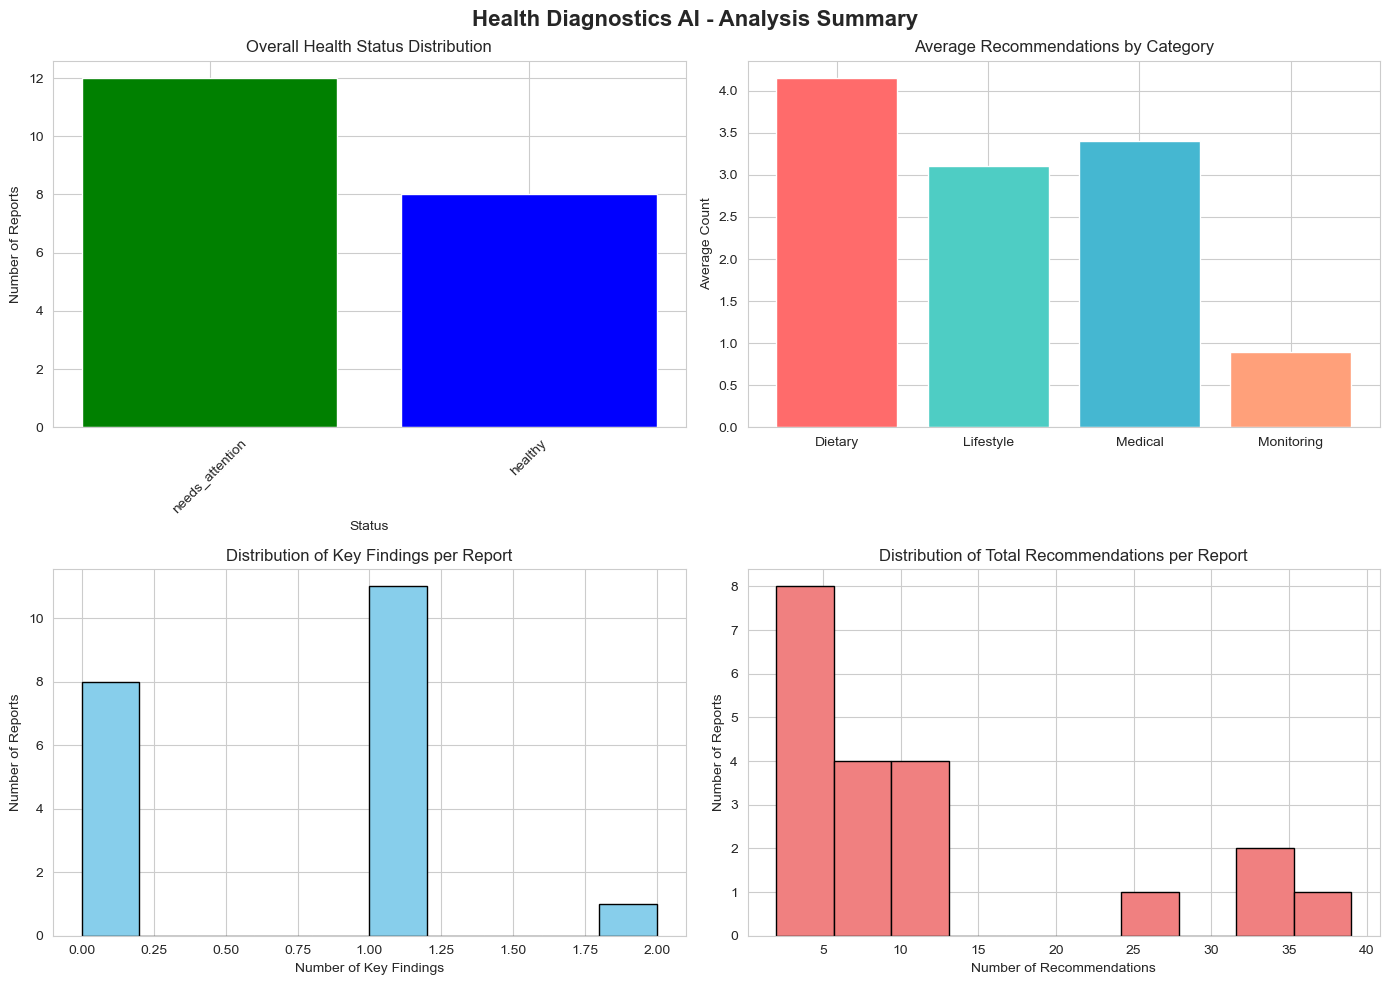


Statistical Summary:
       key_findings  priority_issues  total_recommendations
count     20.000000        20.000000              20.000000
mean       0.650000         1.250000              11.550000
std        0.587143         1.118034              11.794178
min        0.000000         0.000000               2.000000
25%        0.000000         0.000000               2.000000
50%        1.000000         2.000000               9.000000
75%        1.000000         2.000000              13.000000
max        2.000000         3.000000              39.000000


In [9]:
# Cell 9: Generate Statistics Summary
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Health Diagnostics AI - Analysis Summary', fontsize=16, fontweight='bold')

# Plot 1: Overall Status Distribution
status_counts = results_df['overall_status'].value_counts()
axes[0, 0].bar(status_counts.index, status_counts.values, color=['green', 'blue', 'yellow', 'orange', 'red'])
axes[0, 0].set_title('Overall Health Status Distribution')
axes[0, 0].set_xlabel('Status')
axes[0, 0].set_ylabel('Number of Reports')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Average Recommendations by Type
rec_types = ['dietary_recs', 'lifestyle_recs', 'medical_recs', 'monitoring_recs']
rec_means = [results_df[rec_type].mean() for rec_type in rec_types]
rec_labels = ['Dietary', 'Lifestyle', 'Medical', 'Monitoring']
axes[0, 1].bar(rec_labels, rec_means, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0, 1].set_title('Average Recommendations by Category')
axes[0, 1].set_ylabel('Average Count')

# Plot 3: Key Findings Distribution
axes[1, 0].hist(results_df['key_findings'], bins=10, color='skyblue', edgecolor='black')
axes[1, 0].set_title('Distribution of Key Findings per Report')
axes[1, 0].set_xlabel('Number of Key Findings')
axes[1, 0].set_ylabel('Number of Reports')

# Plot 4: Total Recommendations Distribution
axes[1, 1].hist(results_df['total_recommendations'], bins=10, color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Distribution of Total Recommendations per Report')
axes[1, 1].set_xlabel('Number of Recommendations')
axes[1, 1].set_ylabel('Number of Reports')

plt.tight_layout()
plt.savefig('../outputs/analysis_summary.png', dpi=300, bbox_inches='tight')
print("✓ Summary plots saved to outputs/analysis_summary.png")
plt.show()

print("\nStatistical Summary:")
print("="*60)
print(results_df[['key_findings', 'priority_issues', 'total_recommendations']].describe())